# RQ2: Can personality-dependent HCS failures be prevented?

This notebook evaluates two prevention strategies on the runs that fail in RQ1:

- **enforce surge limit** (market side): caps the surge multiplier of both providers at 2.0;
- **call freelance drivers** (human side): restores the reference mix of drivers (37% professional, 63% general population) among the drivers that enter the HCS from that moment on. It is only defined for the populations with professional drivers.

In [1]:
import itertools
import json
import math
import pickle
import re
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

RAW_ROOT = Path("datasets/raw")
PREVENTION_ROOT = Path("datasets/prevention")
RQ1_DIR = Path("analysis_out/rq1-healthiness")
OUT_DIR = Path("analysis_out/rq2-prevention")
OUT_DIR.mkdir(parents=True, exist_ok=True)
AGGREGATE = 600
WINDOW_FILL = 60
CUT = 7200
STRIDE = 20
ANALYSIS_START = 3600 + CUT - AGGREGATE
EVENT_START = 79200
TRIGGER_MIN = 5
SPIKE_GAP_S = 600
MIN_SPIKE_S = 300
PRE_WINDOW_S = 3600
TOP_METRICS = 8
DEMAND = "passengers_new"
FAILED_PARTS = ["rides_not_served", "passengers_cancel"]
EXCLUDED_METRICS = {"rides_failed"}
INDEX_OWN = set(FAILED_PARTS) | {DEMAND, "failed_requests"}
DRIVER_ALIASES = {"car, taxi and van drivers": "driver", "driver": "driver", "general": "general"}
PASSENGER_ALIASES = {"bank tellers": "bank_tellers", "bank_tellers": "bank_tellers", "students": "students", "managers": "managers", "general": "general"}
RUN_FILE_RE = re.compile(r"_dr_(?P<driver>.+?)_pass_(?P<passenger>.+)$")
STRATEGIES = {"call_freelance_drivers": "Call freelance drivers", "enforce_surge_limit": "Enforce surge limit"}
STRATEGY_TAG = {"call_freelance_drivers": "c", "enforce_surge_limit": "s"}
EVENT_DURATION = {"flash_mob": 1800, "underground_alarm": 2700, "boycott_tncs": 3600, "wildcat_strike": 3600, "long_rides": 7200}
EVENTS = {"underground_alarm": "UA", "wildcat_strike": "WS", "flash_mob": "FM",
          "long_rides": "LR", "boycott_tncs": "BT"}
SCENARIO_ORDER = ["normal", "underground_alarm", "wildcat_strike", "flash_mob", "long_rides", "boycott_tncs", 
                  "underground_alarm-flash_mob", "underground_alarm-long_rides", "underground_alarm-wildcat_strike", 
                  "flash_mob-long_rides", "flash_mob-wildcat_strike", "flash_mob-boycott_tncs",
                  "wildcat_strike-long_rides", "wildcat_strike-boycott_tncs", "boycott_tncs-long_rides"]
POPULATIONS = ["baseline", "students", "managers", "bank_tellers", "drivers", "students_drivers", "managers_drivers", "bank_tellers_drivers"]
POPULATION_LABEL = {"baseline": "general", "students": "students", "managers": "managers", "bank_tellers": "bank tellers", "drivers": "drivers",
                    "students_drivers": "students + drivers", "managers_drivers": "managers + drivers", "bank_tellers_drivers": "bank tellers + drivers"}
METRIC_FAMILIES = {
    "demand": ["passengers_new", "passengers_departures", "passengers_arrivals", "passengers_unassigned", "passengers_drivers_ratio"],
    "passenger_decisions": ["passengers_accept", "passengers_reject", "passengers_acceptance_rate", "passengers_cancel", 
                            "passengers_offers_discarded", "passengers_change_provider", "passengers_pickup_accept", "passengers_pickup_reject"],
    "passenger_experience": ["passengers_rating_avg", "passengers_ratings_count", "passengers_no_ratings_count", "rides_waiting_duration_avg"],
    "supply": ["drivers_idle", "drivers_pickup", "drivers_busy", "drivers_starting", "drivers_waiting", "drivers_removed", "drivers_shift_duration_avg",
               "drivers_idle_duration_avg", "drivers_occupied_distance_avg", "drivers_occupied_duration_avg", "drivers_total_length_avg", "drivers_passengers_served"],
    "driver_decisions": ["drivers_accept", "drivers_reject", "drivers_acceptance_rate", "drivers_change_zone", 
                         "drivers_change_provider", "drivers_pickup_accept", "drivers_pickup_reject"],
    "matching": ["rides_offers_generated", "rides_offers_lyft", "rides_offers_uber", "rides_offers_radius_avg", 
                 "rides_dispatched", "rides_partial_acceptances", "rides_in_progress", "rides_not_served"],
    "market": ["drivers_demand_pressure", "rides_offers_price_no_surge_avg", "rides_offers_price_lyft_avg", 
               "rides_offers_price_uber_avg", "rides_offers_surge_lyft_avg", "rides_offers_surge_uber_avg"],
    "trip": ["rides_duration_avg", "rides_length_avg", "traffic_duration_avg", "traffic_length_avg", "traffic_speed_avg"]
}
FAMILY_OF = {m: fam for fam, ms in METRIC_FAMILIES.items() for m in ms}

def family_of(metric: str) -> str:
    return FAMILY_OF.get(metric, "other")

def personality_of(driver_job: str, passenger_job: str) -> str:
    if driver_job == "general":
        return "baseline" if passenger_job == "general" else passenger_job
    return "drivers" if passenger_job == "general" else f"{passenger_job}_drivers"

def event_window(scenario: str) -> tuple[int, int]:
    comps = [] if scenario == "normal" else scenario.split("-")
    duration = max(EVENT_DURATION[c] for c in comps) if comps else min(EVENT_DURATION.values())
    return EVENT_START, EVENT_START + duration

def scenario_label(scenario: str) -> str:
    return "Normal" if scenario == "normal" else " + ".join(EVENTS[e] for e in scenario.split("-"))

In [2]:
%run utils.ipynb

### RQ1 results

In [3]:
if not (RQ1_DIR / "thresholds.json").exists():
    raise FileNotFoundError("run rq1-healthiness.ipynb first: analysis_out/rq1-healthiness/ is missing")
THR = json.loads((RQ1_DIR / "thresholds.json").read_text())
THRESHOLDS = (THR["p99_h"], THR["p99_c"], THR["p99_r"], THR["a"], THR["b"], THR["c"])
P99_H = THR["p99_h"]
print(f"thresholds: hardiness {THR['p99_h']:.4f}, consistency {THR['p99_c']:.4f}, "
      f"resilience {THR['p99_r']}")

rq1 = pd.read_csv(RQ1_DIR / "healthiness_results.csv")
rq1["personality"] = [personality_of(d, p) for d, p in zip(rq1.driver_job, rq1.passenger_job)]
RQ1_ROW = {(r.scenario, r.personality): r for r in rq1.itertuples()}
print(f"RQ1: {len(rq1)} runs, {int(rq1.failure.sum())} HCS failures")

def rq1_index(scenario: str, personality: str) -> np.ndarray:
    """The index series RQ1 computed for a run without prevention."""
    r = RQ1_ROW[(scenario, personality)]
    path = RQ1_DIR / "runs" / f"thresholds_{r.scenario}_{r.driver_job}_{r.passenger_job}_{r.baseline}.pkl"
    with open(path, "rb") as f:
        return np.asarray(pickle.load(f)[0], dtype=float)

thresholds: hardiness 0.2226, consistency 0.0282, resilience 2894
RQ1: 120 runs, 57 HCS failures


In [4]:
def parse_run(path: Path, root: Path) -> dict | None:
    m = RUN_FILE_RE.search(path.stem)
    if m is None:
        return None
    driver = DRIVER_ALIASES.get(m.group("driver").strip().lower())
    passenger = PASSENGER_ALIASES.get(m.group("passenger").strip().lower())
    if driver is None or passenger is None:
        return None
    rel = path.relative_to(root).parts
    scenario = rel[0] if len(rel) > 1 else None
    if scenario is None:
        return None
    return {"scenario": scenario, "driver_job": driver, "passenger_job": passenger,
            "personality": personality_of(driver, passenger), "path": path}

def discover(root: Path) -> pd.DataFrame:
    runs = [parse_run(p, root) for p in sorted(root.rglob("*.csv")) if "_dr_" in p.name]
    return pd.DataFrame([r for r in runs if r])

raw_runs = discover(RAW_ROOT)
RAW_PATH = {(r.scenario, r.personality): r.path for r in raw_runs.itertuples()}
prevention_runs = {s: discover(PREVENTION_ROOT / s) for s in STRATEGIES}
for s, runs in prevention_runs.items():
    print(f"{STRATEGIES[s]}: {len(runs)} runs over {runs.scenario.nunique()} events")

Call freelance drivers: 33 runs over 13 events
Enforce surge limit: 57 runs over 13 events


## 1. When to trigger the strategies

A strategy cannot react before the HCS has shown something, and should not wait longer than it has to. 
For every run that fails in RQ1 and every metric, the hour that precedes the injection defines normality for that run (its median and its robust standard deviation). 
A metric deviates when it stays more than two robust standard deviations away from that median for at least two minutes.

57 failing runs


,n,median,q1,q3
metric,,,,
passengers_unassigned,57.0,1.0,0.4,4.3
passengers_drivers_ratio,57.0,1.6,0.9,4.1
rides_offers_price_uber_avg,57.0,2.9,0.8,6.6
rides_offers_price_no_surge_avg,57.0,2.9,0.7,7.3
rides_offers_price_lyft_avg,57.0,3.9,0.8,19.5
passengers_acceptance_rate,57.0,4.6,2.8,12.8
rides_not_served,57.0,9.5,6.4,12.4
failed_requests (index deviates),57.0,10.4,2.5,14.5
failed_requests (hardiness threshold crossed),57.0,19.9,11.8,31.6


Earliest deviating metric per run: median 0.6 min; 100% of the failing runs show one within 5 minutes


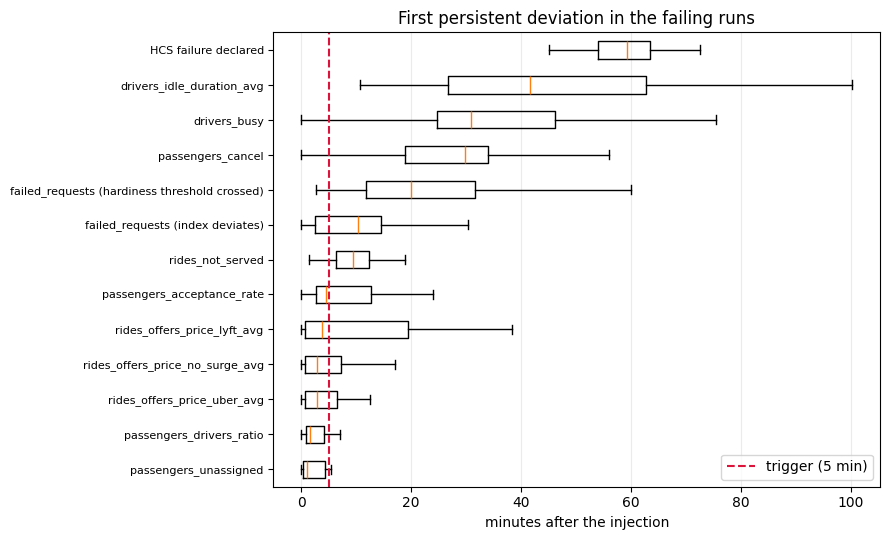

In [5]:
PRE_WINDOW_DETECT_S = 3600
SMOOTH_S = 60
SIGMA = 2.0
PERSIST_S = 120

# The metrics RQ1 identified around the failures, plus the index's own inputs
DETECT_METRICS = [
    "rides_offers_price_no_surge_avg", "rides_offers_price_uber_avg", "rides_offers_price_lyft_avg",
    "passengers_acceptance_rate", "drivers_idle_duration_avg", "passengers_unassigned",
    "passengers_drivers_ratio", "drivers_busy", "rides_not_served", "passengers_cancel"
]

# Minutes from the injection to the first persistent departure from the pre-event band
def first_deviation(t: np.ndarray, x: np.ndarray) -> float | None:
    pre = (t >= EVENT_START - PRE_WINDOW_DETECT_S) & (t < EVENT_START)
    if pre.sum() < 60:
        return None
    ref = np.nanmedian(x[pre])
    scale = 1.4826 * np.nanmedian(np.abs(x[pre] - ref))
    if not np.isfinite(scale) or scale <= 0:
        return None
    after = np.where(t >= EVENT_START)[0]
    out = np.abs(x[after] - ref) > SIGMA * scale
    step = int(np.median(np.diff(t[after][:10]))) or 1
    need = max(1, PERSIST_S // step)
    run = 0
    for i, flag in enumerate(out):
        if not flag:
            run = 0
            continue
        run += 1
        if run >= need:
            return float(t[after][i - run + 1] - EVENT_START) / 60.0
    return None

failing = rq1[rq1.failure]
rows, index_rows = [], []
for r in failing.itertuples():
    frame = pd.read_csv(RAW_PATH[(r.scenario, r.personality)], usecols=lambda c: c in {"timestamp", *DETECT_METRICS})
    frame = fill_missing_data(frame, WINDOW_FILL)
    t = frame["timestamp"].to_numpy()
    for metric in DETECT_METRICS:
        if metric in frame:
            x = frame[metric].rolling(SMOOTH_S, min_periods=1).mean().to_numpy()
            rows.append({"scenario": r.scenario, "personality": r.personality, "metric": metric, "family": family_of(metric), "onset_min": first_deviation(t, x)})
    x = rq1_index(r.scenario, r.personality)
    ts = ANALYSIS_START + np.arange(len(x))
    above = np.flatnonzero((ts >= EVENT_START) & (x > P99_H))
    index_rows.append({"scenario": r.scenario, "personality": r.personality,
                       "index_onset_min": first_deviation(ts, x),
                       "hardiness_crossing_min": (ts[above[0]] - EVENT_START) / 60.0 if len(above) else np.nan,
                       "failure_min": (r.failure_timestamp - EVENT_START) / 60.0})
detection = pd.DataFrame(rows)
detection.to_csv(OUT_DIR / "detection_delay.csv", index=False)
detection_index = pd.DataFrame(index_rows)
detection_index.to_csv(OUT_DIR / "detection_index.csv", index=False)
detection_summary = (detection.dropna(subset=["onset_min"]).groupby("metric").onset_min
                     .agg(n="size", median="median", q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)))
for col, name in (("index_onset_min", "failed_requests (index deviates)"),
                  ("hardiness_crossing_min", "failed_requests (hardiness threshold crossed)"),
                  ("failure_min", "HCS failure declared")):
    v = detection_index[col].dropna()
    detection_summary.loc[name] = [len(v), v.median(), v.quantile(.25), v.quantile(.75)]
detection_summary = detection_summary.sort_values("median")
detection_summary.to_csv(OUT_DIR / "detection_summary.csv")
print(f"{detection.groupby(['scenario', 'personality']).ngroups} failing runs")
display(detection_summary.round(1))
earliest = detection.dropna(subset=["onset_min"]).groupby(["scenario", "personality"]).onset_min.min()
print(f"Earliest deviating metric per run: median {earliest.median():.1f} min; "
      f"{(earliest <= TRIGGER_MIN).mean() * 100:.0f}% of the failing runs show one within {TRIGGER_MIN} minutes")

order = detection_summary.index.tolist()
data = [detection.loc[detection.metric == m, "onset_min"].dropna() if m in DETECT_METRICS
        else detection_index[{"failed_requests (index deviates)": "index_onset_min",
                              "failed_requests (hardiness threshold crossed)": "hardiness_crossing_min",
                              "HCS failure declared": "failure_min"}[m]].dropna()
        for m in order]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(data, vert=False, showfliers=False)
ax.set_yticks(range(1, len(order) + 1), order, fontsize=8)
ax.axvline(TRIGGER_MIN, color="crimson", linestyle="--", label=f"trigger ({TRIGGER_MIN} min)")
ax.set_xlabel("minutes after the injection")
ax.set_title("First persistent deviation in the failing runs")
ax.legend(loc="lower right")
ax.grid(alpha=.25, axis="x")
plt.tight_layout()
plt.savefig(OUT_DIR / "detection_delay.pdf", bbox_inches="tight")
plt.show()

## 2. Running the prevention strategies

In [6]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = fill_missing_data(df.copy(), WINDOW_FILL)
    timestamps = df["timestamp"].to_numpy()
    numeric = df.drop(columns=["timestamp"]).rolling(window=AGGREGATE).mean().round(5)
    numeric.insert(0, "timestamp", timestamps)
    numeric = numeric[3600 + CUT - AGGREGATE:-CUT].reset_index(drop=True)
    return numeric.iloc[::STRIDE].reset_index(drop=True)

def robust_scale(series: pd.Series) -> float:
    # 1.4826 * Median Absolute Deviation (MAD)
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    if values.size == 0:
        return np.nan
    mad = np.median(np.abs(values - np.median(values)))
    scale = 1.4826 * mad
    return scale if scale > 1e-12 else np.nan

def verdict_of(df_raw: pd.DataFrame) -> tuple[pd.Series, float | None]:
    p99_h, p99_c, p99_r, a, b, c = THRESHOLDS
    frame = fill_missing_data(df_raw.copy(), WINDOW_FILL)
    index, exceed_h, exceed_c, exceed_r, consecutive_t = compute_exceeding_timestamps(
        frame, AGGREGATE, CUT, a, b, c, p99_h, p99_c, p99_r)
    failure_ts = find_hcs_failure(exceed_h, exceed_c, exceed_r, consecutive_t, p99_r)
    return index, (failure_ts + ANALYSIS_START if failure_ts > 0 else None)

def find_spikes(index: pd.Series, timestamps: np.ndarray, threshold: float) -> list[dict]:
    above = index.to_numpy() > threshold
    episodes, start = [], None
    for i, flag in enumerate(above):
        if flag and start is None:
            start = i
        elif not flag and start is not None:
            episodes.append((start, i - 1))
            start = None
    if start is not None:
        episodes.append((start, len(above) - 1))
    merged: list[list[int]] = []
    for s, e in episodes:
        if merged and timestamps[s] - timestamps[merged[-1][1]] < SPIKE_GAP_S:
            merged[-1][1] = e
        else:
            merged.append([s, e])
    spikes = []
    for s, e in merged:
        duration = timestamps[e] - timestamps[s]
        if duration < MIN_SPIKE_S:
            continue
        values = index.to_numpy()[s:e + 1]
        spikes.append({"start_ts": float(timestamps[s]), "end_ts": float(timestamps[e]),
                       "duration_s": float(duration), "duration_min": duration / 60.0,
                       "peak": float(values.max()), "mean": float(values.mean()),
                       "area": float(np.sum(np.clip(values - threshold, 0, None)) * STRIDE),
                       "i0": s, "i1": e})
    return spikes

# Exact Shapley split of the index rise into not-served, cancel and demand
def shapley_split(pre: dict, spike: dict) -> dict:
    _, _, _, a, b, c = THRESHOLDS
    factors = ["not_served", "cancel", "demand"]

    def fr(state: dict) -> float:
        return compute_failed_requests(a, b, c, failed=state["not_served"] + state["cancel"], requested=state["demand"])

    contributions = {f: 0.0 for f in factors}
    orders = list(itertools.permutations(factors))
    for order in orders:
        state = dict(pre)
        current = fr(state)
        for f in order:
            state[f] = spike[f]
            new = fr(state)
            contributions[f] += new - current
            current = new
    return {f: v / len(orders) for f, v in contributions.items()}

def analyse_run(run: dict, reference: dict) -> dict:
    df_raw = pd.read_csv(run["path"])
    index, failure_ts = verdict_of(df_raw)
    frame = preprocess(df_raw)
    timestamps = frame["timestamp"].to_numpy()
    index_dec = index.iloc[::STRIDE].reset_index(drop=True)
    index_dec = index_dec.iloc[:len(timestamps)].reset_index(drop=True)
    timestamps = timestamps[:len(index_dec)]
    win_start, win_end = event_window(run["scenario"])
    in_event = (timestamps >= win_start) & (timestamps <= win_end)
    pre_event = (timestamps >= win_start - PRE_WINDOW_S) & (timestamps < win_start)
    spikes = find_spikes(index_dec, timestamps, P99_H)
    cell = {
        "scenario": run["scenario"], "personality": run["personality"],
        "failure": failure_ts is not None,
        "failure_timestamp": failure_ts,
        "fr_mean": float(index_dec.mean()),
        "fr_mean_event": float(index_dec[in_event].mean()) if in_event.any() else np.nan,
        "fr_p99": float(np.percentile(index_dec, 99)),
        "fr_peak": float(index_dec.max()),
        "minutes_above_threshold": float((index_dec.to_numpy() > P99_H).sum() * STRIDE / 60.0),
        "n_spikes": len(spikes),
        "spike_minutes": float(sum(s["duration_min"] for s in spikes)),
        "spike_minutes_in_event": float(sum(
            max(0.0, min(s["end_ts"], win_end) - max(s["start_ts"], win_start)) / 60.0
            for s in spikes)),
    }

    # Spike carrying the failure, or the most severe one
    failing_spike = None
    if spikes:
        if failure_ts is not None:
            failing_spike = next((s for s in spikes if s["start_ts"] <= failure_ts <= s["end_ts"]), None)
        failing_spike = failing_spike or max(spikes, key=lambda s: s["area"])
    if failing_spike is not None:
        s0, s1 = failing_spike["i0"], failing_spike["i1"]
        pre_mask = ((timestamps >= failing_spike["start_ts"] - PRE_WINDOW_S) & (timestamps < failing_spike["start_ts"]))
        spike_slice = slice(s0, s1 + 1)

        def level(column: str, mask) -> float:
            selected = frame[column].to_numpy()[mask]
            return float(np.nanmean(selected)) if len(selected) else np.nan

        pre_state = {"not_served": level("rides_not_served", pre_mask), "cancel": level("passengers_cancel", pre_mask), "demand": level(DEMAND, pre_mask)}
        spike_state = {"not_served": level("rides_not_served", spike_slice), "cancel": level("passengers_cancel", spike_slice), "demand": level(DEMAND, spike_slice)}
        parts = shapley_split(pre_state, spike_state)
        failed_total = spike_state["not_served"] + spike_state["cancel"]
        share_ns = spike_state["not_served"] / failed_total if failed_total else np.nan
        dominant = max(parts, key=lambda k: abs(parts[k]))

        cell.update({
            "spike_start": failing_spike["start_ts"], "spike_end": failing_spike["end_ts"],
            "spike_duration_min": failing_spike["duration_min"], "spike_peak": failing_spike["peak"],
            "spike_mean": failing_spike["mean"],
            "position": ("during" if failing_spike["start_ts"] <= win_end and failing_spike["end_ts"] >= win_start else "outside"),
            "d_not_served": parts["not_served"], "d_cancel": parts["cancel"],
            "d_demand": parts["demand"],
            "share_not_served": share_ns,
            "share_cancel": 1 - share_ns if share_ns == share_ns else np.nan,
            "dominant_driver": dominant,
            "failure_mode": {"not_served": "not-served dominated", "cancel": "cancel dominated", "demand": "demand-driven"}[dominant],
            "not_served_pre": pre_state["not_served"], "not_served_spike": spike_state["not_served"],
            "cancel_pre": pre_state["cancel"], "cancel_spike": spike_state["cancel"]
        })
    else:
        cell.update({"failure_mode": "no spike", "dominant_driver": "none"})

    # Event-window level of every metric: compared below with the run without prevention to say which metrics the strategy actually moves
    levels = {}
    if in_event.any():
        for column in frame.columns:
            if column == "timestamp":
                continue
            value = float(np.nanmean(frame[column].to_numpy()[in_event]))
            if np.isfinite(value):
                levels[column] = value
    cell["window_levels"] = levels

    # Levels of the two failure metrics over the event window, defined for every run
    for column, prefix in (("rides_not_served", "ns"), ("passengers_cancel", "ca")):
        values = frame[column].to_numpy()
        cell[f"{prefix}_pre"] = float(np.nanmean(values[pre_event])) if pre_event.any() else np.nan
        cell[f"{prefix}_in"] = float(np.nanmean(values[in_event])) if in_event.any() else np.nan

    # Metrics most disturbed inside the spike, in robust z against the reference run
    affected = []
    if failing_spike is not None:
        outside = ~in_event
        for column in frame.columns:
            if column == "timestamp" or column in EXCLUDED_METRICS or column in INDEX_OWN:
                continue
            scale = reference["scale"].get(column)
            if scale is None or not np.isfinite(scale):
                continue
            spike_level = float(np.nanmean(frame[column].to_numpy()[s0:s1 + 1]))
            own = float(np.nanmean(frame[column].to_numpy()[outside]))
            ref_level = reference["level"].get(column, np.nan)
            affected.append({"metric": column,
                             "spike_level": spike_level, "own_baseline_level": own,
                             "dev_vs_own": (spike_level - own) / scale,
                             "dev_vs_reference": (spike_level - ref_level) / scale})
        affected.sort(key=lambda r: abs(r["dev_vs_own"]), reverse=True)
    cell["affected"] = affected[:TOP_METRICS]
    cell["trace"] = {"t0": int(timestamps[0]), "dt": STRIDE, "v": [int(round(v * 1000)) for v in index_dec.to_numpy()]}
    return cell

### The runs without prevention

Each run with prevention is paired with the same `(event, personality)` run without prevention.

In [7]:
def base_cell(scenario: str, personality: str) -> dict:
    r = RQ1_ROW[(scenario, personality)]
    x = rq1_index(scenario, personality)[::STRIDE]
    ts = ANALYSIS_START + STRIDE * np.arange(len(x))
    s, e = event_window(scenario)
    inside = (ts >= s) & (ts < e)
    return {"failure": bool(r.failure),
            "failure_timestamp": None if pd.isna(r.failure_timestamp) else float(r.failure_timestamp),
            "fr_mean_event": float(np.nanmean(x[inside])),
            "fr_peak": float(np.nanmax(x)),
            "minutes_above_threshold": float((x > P99_H).sum() * STRIDE / 60.0)}

reference_frame = preprocess(pd.read_csv(RAW_PATH[("normal", "baseline")]))
reference = {"level": {}, "scale": {}}         # For the most disturbed metrics of a run
metric_scale = {}                              # For the effects of a strategy
for column in reference_frame.columns:
    if column == "timestamp":
        continue
    reference["level"][column] = float(pd.to_numeric(reference_frame[column], errors="coerce").mean())
    reference["scale"][column] = robust_scale(reference_frame[column])
    v = reference_frame[column].to_numpy(dtype=float)
    scale = 1.4826 * float(np.nanmedian(np.abs(v - np.nanmedian(v))))
    if not np.isfinite(scale) or scale <= 0:
        scale = float(np.nanstd(v))
    metric_scale[column] = scale if np.isfinite(scale) and scale > 0 else np.nan

# Event-window level of every metric in the failing runs without prevention
needed = sorted({(r.scenario, r.personality) for runs in prevention_runs.values()
                 for r in runs.itertuples()} & {(r.scenario, r.personality) for r in failing.itertuples()})
base_level_rows = []
for scenario, personality in needed:
    frame = preprocess(pd.read_csv(RAW_PATH[(scenario, personality)]))
    s, e = event_window(scenario)
    inside = (frame.timestamp >= s) & (frame.timestamp < e)
    for metric, level in frame.loc[inside].drop(columns=["timestamp"]).mean().items():
        base_level_rows.append({"scenario": scenario, "personality": personality, "metric": metric,
                                "family": family_of(metric), "level": level,
                                "scale": metric_scale.get(metric, np.nan)})
base_levels = pd.DataFrame(base_level_rows)

### The runs with prevention

- `prevented`: the run fails without prevention and passes with it;
- `still fails`: it fails in both; `shift_min` is how far the failure moved (positive: later);
- `still passes`: the run passed without prevention.

In [8]:
def clean_float(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return None if np.isnan(value) else value

def subtract(a, b):
    a, b = clean_float(a), clean_float(b)
    return None if a is None or b is None else a - b

def json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
    if isinstance(value, float):
        return None if np.isnan(value) else round(value, 5)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(f"not JSON serialisable: {type(value)}")

cells_by_strategy = {}
for strategy, runs in prevention_runs.items():
    cells = []
    for run in runs.to_dict("records"):
        cell = analyse_run(run, reference)
        base = base_cell(run["scenario"], run["personality"])
        base_ts = base["failure_timestamp"]
        cell.update({"base_failure": base["failure"], "base_failure_timestamp": base_ts,
                     "base_fr_mean_event": base["fr_mean_event"], "base_fr_peak": base["fr_peak"],
                     "base_minutes_above_threshold": base["minutes_above_threshold"],
                     "d_fr_mean_event": subtract(cell["fr_mean_event"], base["fr_mean_event"]),
                     "d_fr_peak": subtract(cell["fr_peak"], base["fr_peak"]),
                     "d_minutes_above_threshold": subtract(cell["minutes_above_threshold"], base["minutes_above_threshold"])})
        if base["failure"] and not cell["failure"]:
            cell["outcome"] = "prevented"
        elif base["failure"] and cell["failure"]:
            # The failure survives, how far it moved is reported as a number
            cell["outcome"] = "still fails"
            cell["shift_min"] = (cell["failure_timestamp"] - base_ts) / 60.0 if base_ts is not None else None
        elif not base["failure"] and cell["failure"]:
            cell["outcome"] = "new failure"
        else:
            cell["outcome"] = "still passes"
        cells.append(cell)
    cells_by_strategy[strategy] = cells
    out_dir = OUT_DIR / strategy
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([{k: v for k, v in c.items() if k not in ("affected", "trace", "window_levels")}
                  for c in cells]).to_csv(out_dir / "cells.csv", index=False)
    (out_dir / "cells.json").write_text(json.dumps(
        {"strategy": strategy, "label": STRATEGIES[strategy], "threshold": P99_H,
         "cells": [{k: v for k, v in c.items() if k != "window_levels"} for c in cells]},
        default=json_safe, separators=(",", ":")))
    outcomes = pd.Series([c["outcome"] for c in cells]).value_counts().to_dict()
    print(f"{STRATEGIES[strategy]}: {len(cells)} runs -> {out_dir}  {outcomes}")

Call freelance drivers: 33 runs -> analysis_out/rq2-prevention/call_freelance_drivers  {'still fails': 18, 'prevented': 15}


Enforce surge limit: 57 runs -> analysis_out/rq2-prevention/enforce_surge_limit  {'still fails': 45, 'prevented': 12}


### Prevention table

,general,students,managers,bank tellers,drivers,students + drivers,managers + drivers,bank tellers + drivers,prevented
event,,,,,,,,,
Normal,-,-,-,-,-,-,-,-,--
UA,-,s:+2,s:+4,s:+3,c:+2 s:+1,c:-2 s:-12,c:-2 s:+3,c:0 s:+1,0/11
WS,-,-,-,-,-,-,-,-,--
FM,-,-,-,-,-,-,-,c:prevented s:+5,1/2
LR,-,-,-,-,c:prevented s:prevented,c:prevented s:prevented,c:prevented s:prevented,c:prevented s:prevented,8/8
BT,-,-,-,-,c:prevented s:prevented,-,-,c:prevented s:-1,3/4
UA + FM,s:-8,s:-1,s:-4,s:-9,c:0 s:-10,c:0 s:-24,c:-3 s:-1,c:-2 s:+2,0/12
UA + LR,s:+3,s:+9,s:+4,s:+2,c:-2 s:+2,c:0 s:+6,c:+2 s:-10,c:-1 s:0,0/12
UA + WS,s:-5,s:+1,s:-1,s:+1,c:+2 s:-5,c:+1 s:-4,c:0 s:0,c:+4 s:-1,0/12


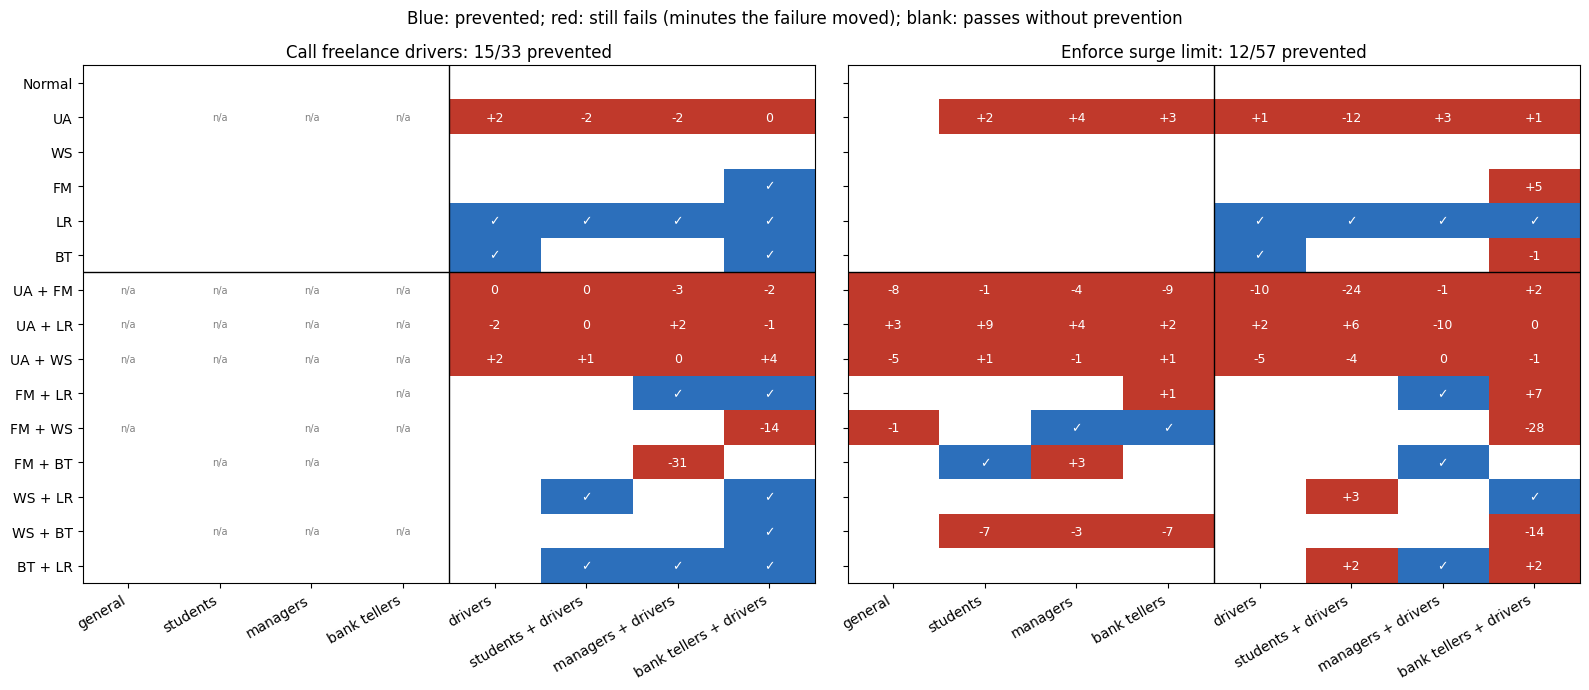

In [9]:
cell_of = {s: {(c["scenario"], c["personality"]): c for c in cells if c["base_failure"]} for s, cells in cells_by_strategy.items()}

def shift_text(v) -> str:
    v = int(round(v))
    return f"{v:+d}" if v else "0"

def entries(scenario: str, personality: str) -> list[tuple[str, dict]]:
    return [(STRATEGY_TAG[s], cell_of[s][(scenario, personality)]) for s in STRATEGIES if (scenario, personality) in cell_of[s]]

def count(items) -> tuple[int, int]:
    return sum(1 for _, c in items if c["outcome"] == "prevented"), len(items)

grid_rows, tex_rows = [], []
for s in SCENARIO_ORDER:
    text_cells, tex_cells, scen_items = [], [], []
    for p in POPULATIONS:
        items = entries(s, p)
        scen_items += items
        if not RQ1_ROW[(s, p)].failure:
            text_cells.append("-")
            tex_cells.append(r"\pass")
            continue
        text_cells.append(" ".join(f"{tag}:prevented" if c["outcome"] == "prevented"
                                   else f"{tag}:{shift_text(c['shift_min'])}" for tag, c in items))
        tex_cells.append(r"\,".join(rf"\pv{{{tag}}}" if c["outcome"] == "prevented"
                                    else rf"\pf{{{tag}}}{{{shift_text(c['shift_min'])}}}"
                                    for tag, c in items))
    n_prev, n = count(scen_items)
    total = f"{n_prev}/{n}" if n else "--"
    grid_rows.append([scenario_label(s)] + text_cells + [total])
    tex_rows.append((s, tex_cells, total))

col_totals = [count([it for s in SCENARIO_ORDER for it in entries(s, p)]) for p in POPULATIONS]
all_items = [it for s in SCENARIO_ORDER for p in POPULATIONS for it in entries(s, p)]
grand = count(all_items)
grid_rows.append(["Prevented"] + [f"{a}/{b}" for a, b in col_totals] + [f"{grand[0]}/{grand[1]}"])
prevention_table = pd.DataFrame(grid_rows, columns=["scenario"] + [POPULATION_LABEL[p] for p in POPULATIONS] + ["prevented"]).set_index("scenario")
prevention_table.to_csv(OUT_DIR / "prevention.csv")
display(prevention_table.rename_axis("event"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, strategy in zip(axes, STRATEGIES):
    grid = np.full((len(SCENARIO_ORDER), len(POPULATIONS)), np.nan)
    for i, s in enumerate(SCENARIO_ORDER):
        for j, p in enumerate(POPULATIONS):
            if not RQ1_ROW[(s, p)].failure:
                continue
            c = cell_of[strategy].get((s, p))
            if c is None:
                ax.text(j, i, "n/a", ha="center", va="center", fontsize=7, color="grey")
                continue
            grid[i, j] = 1.0 if c["outcome"] == "prevented" else 0.0
            ax.text(j, i, "✓" if c["outcome"] == "prevented" else shift_text(c["shift_min"]),
                    ha="center", va="center", fontsize=9, color="white")
    ax.imshow(grid, cmap=ListedColormap(["#c0392b", "#2c6fbb"]), vmin=0, vmax=1,
              aspect="auto")
    ax.set_xticks(range(len(POPULATIONS)), [POPULATION_LABEL[p] for p in POPULATIONS], rotation=30, ha="right")
    ax.set_yticks(range(len(SCENARIO_ORDER)), [scenario_label(s) for s in SCENARIO_ORDER])
    ax.axvline(3.5, color="black", linewidth=1)
    ax.axhline(5.5, color="black", linewidth=1)
    n_prev, n = count([(None, c) for c in cell_of[strategy].values()])
    ax.set_title(f"{STRATEGIES[strategy]}: {n_prev}/{n} prevented")
fig.suptitle("Blue: prevented; red: still fails (minutes the failure moved); blank: passes without prevention")
plt.tight_layout()
plt.savefig(OUT_DIR / "prevention.pdf", bbox_inches="tight")
plt.show()

### Effectiveness and complementarity

In [10]:
summary = {"trigger_min": TRIGGER_MIN, "detection_median_min": {m: round(float(v), 1) for m, v in detection_summary["median"].items()}}
for strategy in STRATEGIES:
    cells = list(cell_of[strategy].values())
    frame = pd.DataFrame(cells)
    prevented = frame.outcome == "prevented"
    shifts = frame.loc[~prevented, "shift_min"]
    summary[strategy] = {
        "prevented": int(prevented.sum()),
        "prevented_per_population": {POPULATION_LABEL[p]: int(prevented[frame.personality == p].sum()) for p in POPULATIONS if (frame.personality == p).any()},
        "still_failing_shift_min": {"min": round(float(shifts.min()), 1), "max": round(float(shifts.max()), 1), "median": round(float(shifts.median()), 1)},
    }
    print(f"{STRATEGIES[strategy]}:")
    for k in ("prevented", "prevented_per_population", "still_failing_shift_min"):
        print(f"  {k}: {summary[strategy][k]}")

base_failing = {(r.scenario, r.personality) for r in failing.itertuples()}
prev_c = {k for k, c in cell_of["call_freelance_drivers"].items() if c["outcome"] == "prevented"}
prev_s = {k for k, c in cell_of["enforce_surge_limit"].items() if c["outcome"] == "prevented"}
summary["complementarity"] = {"both": len(prev_c & prev_s), "only_call_freelance_drivers": len(prev_c - prev_s),
                              "only_enforce_surge_limit": len(prev_s - prev_c),
                              "any": len(prev_c | prev_s)}
summary["prevention_table_total"] = [grand[0], grand[1]]
print("\nComplementarity:", summary["complementarity"])
print("Prevention table total:", summary["prevention_table_total"][0])

Call freelance drivers:
  prevented: 15
  prevented_per_population: {'drivers': 2, 'students + drivers': 3, 'managers + drivers': 3, 'bank tellers + drivers': 7}
  still_failing_shift_min: {'min': -31.1, 'max': 3.8, 'median': -0.2}
Enforce surge limit:
  prevented: 12
  prevented_per_population: {'general': 0, 'students': 1, 'managers': 1, 'bank tellers': 1, 'drivers': 2, 'students + drivers': 1, 'managers + drivers': 4, 'bank tellers + drivers': 2}
  still_failing_shift_min: {'min': -27.5, 'max': 8.7, 'median': 0.2}

Complementarity: {'both': 8, 'only_call_freelance_drivers': 7, 'only_enforce_surge_limit': 4, 'any': 19}
Prevention table total: 27


## 3. Strategies effect on the metrics

For every metric, the event-window level with prevention is compared with the level without prevention, run by run, in robust z.

In [11]:
def prevention_effects(cells: list[dict]) -> dict:
    key = base_levels.set_index(["scenario", "personality", "metric"])
    rows = []
    for c in cells:
        for metric, level in (c.get("window_levels") or {}).items():
            if metric in INDEX_OWN:
                continue
            try:
                base = key.loc[(c["scenario"], c["personality"], metric)]
            except KeyError:
                continue
            scale = float(base["scale"]) if pd.notna(base["scale"]) else float("nan")
            if not scale or math.isnan(scale):
                continue
            rows.append({"metric": metric, "family": base["family"], "outcome": c.get("outcome"),
                         "dz": (float(level) - float(base["level"])) / scale})
    if not rows:
        return {}
    frame = pd.DataFrame(rows)
    moved = (frame.groupby(["metric", "family"]).dz.mean().reset_index().assign(_a=lambda x: x.dz.abs()).sort_values("_a", ascending=False))
    families = (frame.assign(_a=frame.dz.abs()).groupby("family")._a.mean().sort_values(ascending=False))
    prevented = frame[frame.outcome == "prevented"]
    still = frame[frame.outcome == "still fails"]
    separating = pd.DataFrame()
    if len(prevented) and len(still):
        a = prevented.groupby(["metric", "family"]).dz.mean()
        b = still.groupby(["metric", "family"]).dz.mean()
        gap = (a - b).dropna().reset_index(name="gap")
        gap["prevented"] = gap.set_index(["metric", "family"]).index.map(a)
        gap["stillFails"] = gap.set_index(["metric", "family"]).index.map(b)
        separating = gap.assign(_a=gap.gap.abs()).sort_values("_a", ascending=False)

    def r(v, nd=2):
        return None if pd.isna(v) else round(float(v), nd)

    return {
        "moved": [{"m": x.metric, "f": x.family, "dz": r(x.dz)} for x in moved.head(TOP_METRICS).itertuples()],
        "families": [{"f": i, "v": r(v)} for i, v in families.head(6).items()],
        "separating": [{"m": x.metric, "f": x.family, "gap": r(x.gap), "prevented": r(x.prevented),
                        "stillFails": r(x.stillFails)} for x in separating.head(TOP_METRICS).itertuples()],
        "nMetrics": int(frame.metric.nunique()),
        "_moved": moved.drop(columns="_a"), "_separating": separating.drop(columns="_a", errors="ignore"),
    }

effects = {}
for strategy, cells in cells_by_strategy.items():
    shown = [c for c in cells if c.get("base_failure") is True]
    eff = prevention_effects(shown)
    eff.pop("_moved").to_csv(OUT_DIR / strategy / "effects_moved.csv", index=False)
    eff.pop("_separating").to_csv(OUT_DIR / strategy / "effects_separating.csv", index=False)
    (OUT_DIR / strategy / "effects.json").write_text(json.dumps(eff, indent=1))
    effects[strategy] = eff
    print(f"\n{STRATEGIES[strategy]}")
    print("moves:     ", "; ".join(f"{m['m']} {m['dz']:+.2f}" for m in eff["moved"][:5]))
    print("families:  ", "; ".join(f"{m['f']} {m['v']:.2f}" for m in eff["families"][:4]))
    print("separates: ", "; ".join(f"{m['m']} {m['prevented']:+.2f} vs {m['stillFails']:+.2f} (gap {m['gap']:+.2f})" for m in eff["separating"][:5]))

# The metric effects complete the summary of section 2
for strategy in STRATEGIES:
    summary[strategy].update({
        "moved": effects[strategy]["moved"][:5],
        "families": effects[strategy]["families"][:4],
        "separating": effects[strategy]["separating"][:5],
    })
(OUT_DIR / "rq2_summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nWrote {OUT_DIR / 'rq2_summary.json'}")


Call freelance drivers
moves:      drivers_acceptance_rate +0.80; passengers_rating_avg +0.78; drivers_starting +0.35; rides_failed -0.33; drivers_removed -0.28
families:   other 0.38; market 0.35; passenger_experience 0.28; supply 0.23
separates:  passengers_rating_avg +1.31 vs +0.34 (gap +0.98); drivers_acceptance_rate +0.98 vs +0.64 (gap +0.34); rides_offers_price_uber_avg -0.17 vs +0.16 (gap -0.33); rides_offers_price_no_surge_avg -0.16 vs +0.15 (gap -0.31); rides_offers_price_lyft_avg -0.15 vs +0.13 (gap -0.28)

Enforce surge limit
moves:      drivers_acceptance_rate +0.09; rides_offers_radius_avg -0.05; drivers_pickup_reject -0.05; drivers_occupied_duration_avg +0.03; drivers_occupied_distance_avg +0.03
families:   market 0.33; other 0.26; supply 0.20; trip 0.14
separates:  drivers_busy -0.14 vs +0.04 (gap -0.18); rides_offers_price_lyft_avg -0.12 vs +0.04 (gap -0.17); rides_offers_price_uber_avg -0.09 vs +0.05 (gap -0.14); rides_offers_price_no_surge_avg -0.10 vs +0.05 (gap -0.